# Random Forest Model Development and Optimization

## Project: Machine Learning-Based U.S. Residential Rental Price Estimation System

This notebook documents the development and optimization of the Random Forest Regression model for predicting residential rental prices in the United States.

### Objectives

- Develop a Random Forest Regression model for rental price prediction.
- Apply an appropriate validation strategy while preventing data leakage.
- Establish a baseline Random Forest model.
- Evaluate model performance using MAE, RMSE, and R².
- Investigate model overfitting and generalization performance.
- Perform controlled hyperparameter experiments.
- Compare the baseline and tuned Random Forest models.
- Analyse feature importance and model prediction errors.
- Select and save the final Random Forest model for integration into the project.

### Individual Contribution

**Model:** Random Forest Regressor  
**Contributor:** Thiwanka

This notebook focuses specifically on the Random Forest model development, experimentation, optimization, and interpretation.

## 1. Leakage-Safe Preprocessing

### 1.1 Loading the Raw Training and Test Data

The preprocessing decisions were established during Evaluation 1. In this stage, the raw training data is used to ensure that any learned preprocessing operation, particularly target encoding, is fitted only on the training portion of each cross-validation fold.

The raw test set is loaded for completeness but will remain completely untouched during model development and cross-validation. It will only be used once for the final model evaluation.

The following datasets are used:

- `raw_train.csv` — used for model development and cross-validation
- `raw_test.csv` — reserved for final evaluation

In [1]:
import pandas as pd
import numpy as np

# Load raw training and test data
train_df = pd.read_csv("../data/raw_train.csv")
test_df = pd.read_csv("../data/raw_test.csv")

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Training shape: (143679, 17)
Test shape: (35920, 17)


,region,type,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished,laundry_options,parking_options,lat,long,state,price
0,binghamton,apartment,1700,3,1.0,0,0,0,0,0,0,w/d hookups,Unknown,42.0953,-75.9269,ny,985
1,sarasota-bradenton,apartment,840,1,1.0,0,0,1,0,0,0,Unknown,Unknown,27.2427,-82.4751,fl,1210
2,"quad cities, IA/IL",apartment,940,2,1.0,0,0,0,0,0,0,laundry on site,street parking,41.4906,-90.4980,il,775
3,seattle-tacoma,house,900,2,1.0,0,0,1,0,0,0,Unknown,Unknown,47.6339,-122.3480,wa,1650
4,tyler / east TX,apartment,775,2,1.0,0,0,1,0,0,0,w/d in unit,off-street parking,31.9563,-95.2691,tx,685


### 1.2 Defining the Features and Target

The target variable for this regression problem is `price`, representing the rental price of a residential property.

All remaining columns are initially treated as predictor variables.

The feature set follows the preprocessing decisions established during Evaluation 1. Identifying the target separately helps prevent accidental inclusion of the target variable as an input feature, which would cause severe target leakage.

In [2]:
# Separate features and target
X = train_df.drop(columns=["price"])
y = train_df["price"]

X_test = test_df.drop(columns=["price"])
y_test = test_df["price"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Test feature matrix shape:", X_test.shape)
print("Test target shape:", y_test.shape)

Feature matrix shape: (143679, 16)
Target shape: (143679,)
Test feature matrix shape: (35920, 16)
Test target shape: (35920,)


### 1.3 Cross-Validation Strategy

To obtain a reliable estimate of model generalization, **3-fold cross-validation** will be used during Random Forest model development.

The training data is divided into three folds. In each iteration:

1. Two folds are used for model training.
2. One fold is held out for validation.
3. The target encoder is fitted only on the training portion.
4. The fitted encoder is used to transform both the training and validation portions.
5. The Random Forest model is trained on the transformed training data.
6. Predictions are generated for the validation fold.
7. MAE, RMSE, and R² are calculated.

This process is repeated three times so that every training observation is used for validation exactly once.

### Why 3-Fold Cross-Validation?

A 3-fold strategy provides a reasonable balance between reliable validation and computational cost. The dataset contains approximately 144,000 training records, and Random Forest training is computationally more expensive than simpler regression models. Therefore, 3-fold cross-validation provides sufficient validation coverage while keeping the experiment practical for the available hardware.

The test dataset remains completely untouched during this process.

In [3]:
from sklearn.model_selection import KFold

# Define 3-fold cross-validation
kf = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("Number of folds:", kf.get_n_splits(X))

Number of folds: 3


### 1.4 Define Feature Groups

The raw training data contains numerical, categorical, and binary features. These feature groups are defined so that each type of variable can receive the appropriate preprocessing before being provided to the Random Forest model.


In [4]:
# Define feature groups

numerical_features = [
    "sqfeet",
    "beds",
    "baths",
    "lat",
    "long"
]

categorical_features = [
    "region",
    "type",
    "laundry_options",
    "parking_options",
    "state"
]

binary_features = [
    "cats_allowed",
    "dogs_allowed",
    "smoking_allowed",
    "wheelchair_access",
    "electric_vehicle_charge",
    "comes_furnished"
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Binary features:", binary_features)

Numerical features: ['sqfeet', 'beds', 'baths', 'lat', 'long']
Categorical features: ['region', 'type', 'laundry_options', 'parking_options', 'state']
Binary features: ['cats_allowed', 'dogs_allowed', 'smoking_allowed', 'wheelchair_access', 'electric_vehicle_charge', 'comes_furnished']


### 1.5 Build the Preprocessing Pipeline

Numerical features are imputed using the median. Categorical features are imputed using the most frequent value and converted into numerical representations using one-hot encoding. Binary features are passed through without additional transformation.

The preprocessing is fitted separately within each cross-validation training fold to reduce the risk of information leakage.


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical preprocessing
# Random Forest does not require feature scaling.
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

print("Basic preprocessing components defined successfully.")

Basic preprocessing components defined successfully.


### 1.6 Leakage-Safe Target Encoding for Region

The `region` feature has a large number of unique categories. Therefore, target encoding is used to represent each region numerically based on the average rental price observed in the training data.

To avoid data leakage, the encoding will be learned only from the training portion of each cross-validation fold and then applied to both the training and validation portions.


In [6]:
from sklearn.model_selection import KFold

def target_encode_train_valid(
    X_train,
    y_train,
    X_valid,
    column="region",
    smoothing=10
):
    # Calculate global mean from training data only
    global_mean = y_train.mean()

    # Calculate category statistics from training data
    stats = pd.DataFrame({
        "region": X_train[column],
        "target": y_train.values
    }).groupby("region")["target"].agg(["mean", "count"])

    # Apply smoothing
    stats["encoded"] = (
        (stats["count"] * stats["mean"] + smoothing * global_mean)
        / (stats["count"] + smoothing)
    )

    # Map encoding to training and validation data
    train_encoded = X_train[column].map(stats["encoded"])
    valid_encoded = X_valid[column].map(stats["encoded"])

    # Unseen validation regions use the training global mean
    train_encoded = train_encoded.fillna(global_mean)
    valid_encoded = valid_encoded.fillna(global_mean)

    # Remove original region column
    X_train_encoded = X_train.drop(columns=[column]).copy()
    X_valid_encoded = X_valid.drop(columns=[column]).copy()

    # Add encoded region
    X_train_encoded["region_encoded"] = train_encoded
    X_valid_encoded["region_encoded"] = valid_encoded

    return X_train_encoded, X_valid_encoded

### 1.7 Preprocessing After Target Encoding

After `region` is converted into the numerical `region_encoded` feature, the remaining numerical, categorical, and binary features are processed using the same preprocessing approach established during Evaluation 1.


In [7]:
other_categorical_features = [
    "type",
    "laundry_options",
    "parking_options",
    "state"
]

print("Other categorical features:", other_categorical_features)

Other categorical features: ['type', 'laundry_options', 'parking_options', 'state']


### 1.8 Combining the Preprocessing Components

The target-encoded `region_encoded` feature is combined with the remaining numerical features. The numerical, categorical, and binary preprocessing components are then combined into a single `ColumnTransformer` that can be fitted separately within each cross-validation fold.

In [8]:
processed_numerical_features = numerical_features + ["region_encoded"]

preprocessor = ColumnTransformer([
    (
        "numerical",
        numerical_pipeline,
        processed_numerical_features
    ),
    (
        "categorical",
        categorical_pipeline,
        other_categorical_features
    ),
    (
        "binary",
        "passthrough",
        binary_features
    )
])

print("Preprocessing pipeline created successfully.")
print("Numerical features:", processed_numerical_features)

Preprocessing pipeline created successfully.
Numerical features: ['sqfeet', 'beds', 'baths', 'lat', 'long', 'region_encoded']


### 1.9 Cross-Validation Training and Evaluation

A 3-fold cross-validation procedure is used to train and evaluate the Random Forest regression model. In each fold, the dataset is divided into separate training and validation subsets.

The preprocessing steps are fitted only on the training fold and then applied to both the training and validation folds to prevent data leakage. The `region` feature is target encoded using information from the training fold only.

The rental price target is log-transformed before model training to reduce the influence of highly skewed price values. After prediction, the values are converted back to the original price scale for evaluation.

For each fold, the Random Forest model is trained and evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R². The results from all three folds are stored for comparison and later analysis.

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Store results from each cross-validation fold
fold_results = []

print("Starting 3-fold cross-validation...")

for fold, (train_idx, valid_idx) in enumerate(kf.split(X), start=1):

    print(f"\nFold {fold}")
    print("-" * 30)

    # 1. Split training and validation data
    X_train_fold = X.iloc[train_idx].copy()
    X_valid_fold = X.iloc[valid_idx].copy()

    y_train_fold = y.iloc[train_idx].copy()
    y_valid_fold = y.iloc[valid_idx].copy()

    print("Training rows:", len(X_train_fold))
    print("Validation rows:", len(X_valid_fold))

    # 2. Target encode region
    X_train_encoded, X_valid_encoded = target_encode_train_valid(
        X_train_fold,
        y_train_fold,
        X_valid_fold,
        column="region",
        smoothing=10
    )

    # 3. Fit preprocessing on training fold
    preprocessor.fit(X_train_encoded)

    X_train_processed = preprocessor.transform(
        X_train_encoded
    )

    X_valid_processed = preprocessor.transform(
        X_valid_encoded
    )

    # 4. Log-transform target
    y_train_log = np.log1p(y_train_fold)
    y_valid_original = y_valid_fold.values

    # 5. Train Random Forest
    rf_model = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=2
    )

    rf_model.fit(
        X_train_processed,
        y_train_log
    )

    # 6. Generate predictions
    y_valid_pred_log = rf_model.predict(
        X_valid_processed
    )

    y_valid_pred = np.expm1(
        y_valid_pred_log
    )

    # 7. Calculate evaluation metrics
    mae = mean_absolute_error(
        y_valid_original,
        y_valid_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_valid_original,
            y_valid_pred
        )
    )

    r2 = r2_score(
        y_valid_original,
        y_valid_pred
    )

    # 8. Store fold results
    fold_results.append({
        "Fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}")


# Display all fold results
results_df = pd.DataFrame(fold_results)

print("\nCross-validation results:")
print(results_df)

Starting 3-fold cross-validation...

Fold 1
------------------------------
Training rows: 95786
Validation rows: 47893
MAE:  169.54
RMSE: 316.68
R²:   0.7759

Fold 2
------------------------------
Training rows: 95786
Validation rows: 47893
MAE:  170.52
RMSE: 321.19
R²:   0.7725

Fold 3
------------------------------
Training rows: 95786
Validation rows: 47893
MAE:  170.60
RMSE: 318.74
R²:   0.7783

Cross-validation results:
   Fold         MAE        RMSE        R2
0     1  169.538678  316.678161  0.775859
1     2  170.521514  321.194981  0.772498
2     3  170.598013  318.738116  0.778339


### 1.10 Applying Fold-Specific Preprocessing

For each cross-validation fold, the preprocessing pipeline is fitted using only the training portion of the data. The fitted pipeline is then applied to both the training and validation portions.

This ensures that information from the validation data is not used during preprocessing and helps prevent data leakage.

### 1.11 Preparing the Target Variable

The rental price target is log-transformed using the natural logarithm with `log1p()` before model training. This transformation helps reduce the influence of highly skewed rental-price values.

After prediction, the logarithmic predictions are converted back to the original rental-price scale using `expm1()` for evaluation.

### 1.12 Training the Random Forest Model

A Random Forest Regressor is trained separately within each cross-validation fold using the processed training data.

The model is configured with 100 decision trees and a fixed random state to ensure reproducible results. Parallel processing is enabled using two CPU cores.


### 1.13 Generating Predictions

The trained Random Forest model generates predictions for the validation portion of each fold.

The predicted values are initially on the log-transformed scale and are converted back to the original rental-price scale before calculating the evaluation metrics.

### 1.14 Evaluating Model Performance

The model is evaluated separately for each cross-validation fold using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R².

The results from all three folds are stored and compared to assess the consistency of the model's performance across different validation subsets.

In [19]:
# Calculate the average cross-validation performance

cv_mean = results_df[["MAE", "RMSE", "R2"]].mean()

print("Average Cross-Validation Performance")
print("-----------------------------------")
print(f"Mean MAE:  {cv_mean['MAE']:.2f}")
print(f"Mean RMSE: {cv_mean['RMSE']:.2f}")
print(f"Mean R²:   {cv_mean['R2']:.4f}")

Average Cross-Validation Performance
-----------------------------------
Mean MAE:  170.22
Mean RMSE: 318.87
Mean R²:   0.7756


### 1.15 Final Model Training and Test Evaluation

After completing 3-fold cross-validation, the Random Forest model is retrained using the complete training dataset. The preprocessing steps are fitted using the full training data, and the trained model is then evaluated on the untouched test dataset.

The test dataset is used only for final evaluation and is not involved in model training or preprocessing parameter estimation. This provides an independent assessment of how the final model performs on unseen data.

In [20]:
# Separate features and target for final model training

X_full = train_df.drop(columns=["price"])
y_full = train_df["price"]

X_test_final = test_df.drop(columns=["price"])
y_test_final = test_df["price"]

print("Full training shape:", X_full.shape)
print("Test shape:", X_test_final.shape)

Full training shape: (143679, 16)
Test shape: (35920, 16)


In [21]:
# Apply target encoding to the region feature
# Encoding is fitted using the full training data only

X_full_encoded, X_test_encoded = target_encode_train_valid(
    X_full,
    y_full,
    X_test_final,
    column="region",
    smoothing=10
)

print("Encoded training shape:", X_full_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)


Encoded training shape: (143679, 16)
Encoded test shape: (35920, 16)


### 1.16 Final Training Data Preprocessing

The preprocessing pipeline is fitted using the complete training dataset after applying target encoding to the `region` feature.

The fitted preprocessing pipeline is then used to transform both the training and test datasets. Missing numerical values are handled using median imputation, while missing categorical values are replaced using the most frequent category. The remaining categorical variables are one-hot encoded, and binary features are passed through unchanged.

The preprocessing parameters are learned only from the training data to prevent information from the test set from influencing the final model.

In [22]:
# Fit preprocessing using the complete training data

preprocessor.fit(X_full_encoded)

X_full_processed = preprocessor.transform(X_full_encoded)
X_test_processed = preprocessor.transform(X_test_encoded)

print("Processed training shape:", X_full_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (143679, 89)
Processed test shape: (35920, 89)


### 1.17 Preparing the Target Variable for Final Training

The rental price target is log-transformed using `log1p()` before training the final Random Forest model. This transformation reduces the effect of the right-skewed rental-price distribution and allows the model to learn from a more stable target scale.

The original test-set prices are retained separately so that the final predictions can be converted back to the original price scale and evaluated using MAE, RMSE, and R².

In [23]:
# Log-transform the training target
# Keep the original test target for final evaluation

y_full_log = np.log1p(y_full)
y_test_original = y_test_final.values

print("Training target shape:", y_full_log.shape)
print("Test target shape:", y_test_original.shape)
print("Target transformation: log1p")

Training target shape: (143679,)
Test target shape: (35920,)
Target transformation: log1p


### 1.18 Training the Final Random Forest Model

The final Random Forest Regressor is trained using the complete training dataset after preprocessing. The model uses 100 decision trees and the same configuration applied during cross-validation to maintain consistency with the validated model.

The model is trained using the log-transformed rental-price target.

In [24]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the final Random Forest model
final_rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=2
)

# Train the model on the complete training dataset
final_rf_model.fit(
    X_full_processed,
    y_full_log
)

print("Final Random Forest model training completed.")

Final Random Forest model training completed.


### 1.19 Generating Predictions on the Test Set

The trained final Random Forest model is used to generate rental-price predictions for the untouched test dataset.

The model produces predictions on the logarithmic target scale because it was trained using the log-transformed rental price. The predictions are therefore converted back to the original rental-price scale using the inverse transformation before evaluation.

In [25]:
# Generate predictions for the unseen test data

y_test_pred_log = final_rf_model.predict(
    X_test_processed
)

# Convert predictions back to the original price scale
y_test_pred = np.expm1(
    y_test_pred_log
)

print("Test predictions generated successfully.")
print("Number of predictions:", len(y_test_pred))
print("Sample predictions:", y_test_pred[:5])

Test predictions generated successfully.
Number of predictions: 35920
Sample predictions: [1252.47856957 4323.3515266   931.73132628  736.86026849 1357.12118248]


### 1.20 Final Test Set Evaluation

The final Random Forest model is evaluated on the untouched test dataset using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R².

The predictions have been converted back to the original rental-price scale before evaluation. The test-set performance provides an independent measure of how well the final model generalizes to unseen rental listings.

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate final test-set metrics
mae_test = mean_absolute_error(
    y_test_original,
    y_test_pred
)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test_original,
        y_test_pred
    )
)

r2_test = r2_score(
    y_test_original,
    y_test_pred
)

print("Final Test Set Performance")
print("-" * 35)
print(f"MAE  : {mae_test:.2f}")
print(f"RMSE : {rmse_test:.2f}")
print(f"R²   : {r2_test:.4f}")

Final Test Set Performance
-----------------------------------
MAE  : 159.09
RMSE : 303.69
R²   : 0.7918


### 1.21 Summary of Final Model Performance

The final Random Forest model achieved an MAE of approximately $159.09, an RMSE of approximately $303.69, and an R² of 0.7918 on the unseen test dataset.

The 3-fold cross-validation results showed similar performance, with an average MAE of $170.22, RMSE of $318.87, and R² of 0.7756. The consistency between cross-validation and test-set performance indicates that the model provides stable predictions on unseen rental listings.

The final test-set metrics are retained as the primary performance results for the trained Random Forest model.

In [27]:
# Store final model performance for later comparison

final_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae_test, rmse_test, r2_test]
})

print("Final Random Forest Performance:")
display(final_results)

Final Random Forest Performance:


,Metric,Value
0,MAE,159.089913
1,RMSE,303.686917
2,R²,0.791790


### 1.22 Feature Importance Analysis

Feature importance is analyzed to identify which input variables contribute most to the predictions made by the final Random Forest model.

The Random Forest calculates an importance value for each processed feature based on its contribution to reducing prediction error across the decision trees. These importance values are used to understand which characteristics of rental listings have the greatest influence on the model's predictions.

In [28]:
# Extract feature names from the fitted preprocessing pipeline

feature_names = preprocessor.get_feature_names_out()

# Get feature importance values from the trained Random Forest
importance_values = final_rf_model.feature_importances_

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display the top 20 features
print("Top 20 Most Important Features:")
display(feature_importance_df.head(20))

Top 20 Most Important Features:


,Feature,Importance
0,numerical__region_encoded,0.394191
1,numerical__sqfeet,0.184669
2,numerical__long,0.091845
3,numerical__lat,0.085044
4,numerical__baths,0.027872
5,categorical__laundry_options_w/d in unit,0.025464
6,numerical__beds,0.019939
7,binary__comes_furnished,0.012206
8,categorical__type_house,0.009547
9,categorical__parking_options_Unknown,0.009508


### 1.23 Visualizing Feature Importance

The feature importance values are visualized to provide a clearer comparison of the variables used by the final Random Forest model.

The top 15 features are displayed because they account for the most important predictive contributions in the trained model. This visualization helps identify the main factors used by the model when estimating rental prices.

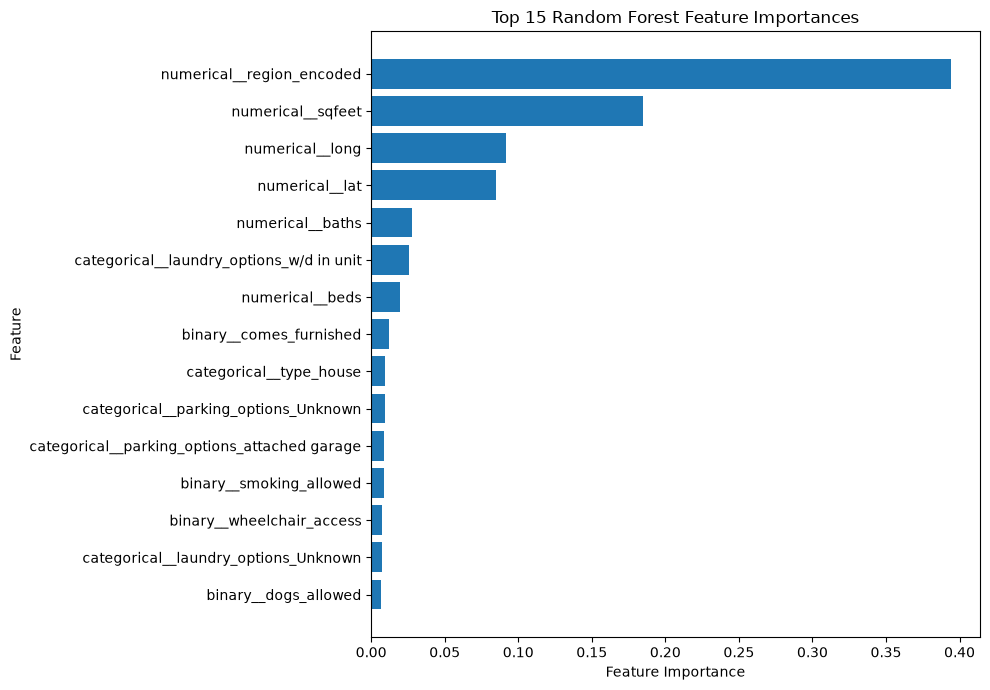

In [29]:
import matplotlib.pyplot as plt

# Select the top 15 features
top_features = feature_importance_df.head(15).sort_values(
    by="Importance",
    ascending=True
)

# Create horizontal bar chart
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

### 1.24 Interpretation of Feature Importance

The feature importance analysis shows that `region_encoded` is the most influential feature in the Random Forest model, with an importance value of approximately 0.394. This indicates that regional information provides substantial predictive information for estimating rental prices.

`sqfeet` is the second most important feature, with an importance of approximately 0.185, showing that property size also contributes considerably to the model's predictions.

The geographic features `long` and `lat` have importance values of approximately 0.092 and 0.085 respectively, indicating that geographical location is another important source of predictive information.

Property characteristics such as `baths` and `beds` have lower individual importance, while features related to furnishing, parking, smoking permissions, accessibility, and pet policies have comparatively smaller contributions.

These importance values represent the contribution of features to the model's predictive decisions and should not be interpreted as causal effects on rental prices.

### 1.25 Actual vs Predicted Rental Prices

The actual rental prices are compared with the prices predicted by the final Random Forest model. A scatter plot is used to visualize the relationship between the actual and predicted values.

A reference line representing perfect predictions is included. Predictions that are closer to this line indicate smaller prediction errors, while larger deviations indicate greater prediction errors.

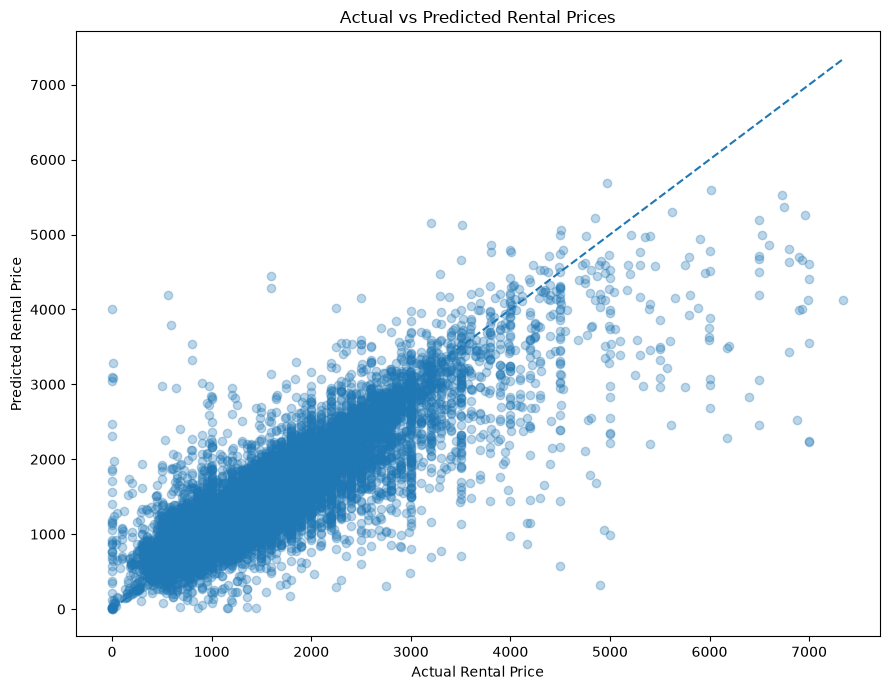

In [30]:
# Plot actual vs predicted rental prices

plt.figure(figsize=(9, 7))

plt.scatter(
    y_test_original,
    y_test_pred,
    alpha=0.3
)

# Reference line for perfect predictions
min_price = min(y_test_original.min(), y_test_pred.min())
max_price = max(y_test_original.max(), y_test_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Rental Price")
plt.ylabel("Predicted Rental Price")
plt.title("Actual vs Predicted Rental Prices")

plt.tight_layout()
plt.show()

### 1.26 Interpretation of Actual vs Predicted Results

The actual-versus-predicted plot shows a clear positive relationship between the observed and predicted rental prices. A large proportion of the observations are distributed around the diagonal reference line, which represents perfect predictions.

The concentration of observations around the line indicates that the Random Forest model is able to capture the general relationship between the property characteristics and rental prices.

However, the dispersion of points becomes wider for some higher-priced properties. This indicates that the model produces larger prediction errors for certain expensive rental listings.

Overall, the visualization is consistent with the final test-set R² value of 0.7918, indicating that the model captures a substantial proportion of the variation in rental prices on unseen data.

### 1.27 Residual Analysis

Residuals represent the difference between the actual rental price and the price predicted by the final Random Forest model.

Residuals are calculated as:

Residual = Actual Price − Predicted Price

A residual close to zero indicates a small prediction error. Positive residuals indicate that the model underestimated the rental price, while negative residuals indicate that the model overestimated the rental price.

The distribution of residuals is analyzed to identify the overall error pattern of the final model.

In [31]:
# Calculate residuals

residuals = y_test_original - y_test_pred

print("Residual Summary")
print("-" * 35)
print(f"Mean residual   : {residuals.mean():.2f}")
print(f"Median residual : {np.median(residuals):.2f}")
print(f"Minimum residual: {residuals.min():.2f}")
print(f"Maximum residual: {residuals.max():.2f}")

Residual Summary
-----------------------------------
Mean residual   : 27.64
Median residual : 0.51
Minimum residual: -4000.34
Maximum residual: 4776.39


What they tell us
Mean residual = +27.64 → on average, actual prices are about $27.64 higher than predictions, so there is a small overall underprediction.
Median residual = +$0.51 → the typical prediction is extremely close to the actual value in terms of the median residual.
Minimum = −$4,000.34 → there is at least one case where the model overpredicted by about $4,000.
Maximum = +$4,776.39 → there is at least one case where the model underpredicted by about $4,776.

### 1.28 Residual Distribution

The distribution of residuals is visualized to examine the prediction-error pattern of the final Random Forest model.

A residual of zero represents an exact prediction. Residuals greater than zero indicate underprediction, while residuals below zero indicate overprediction.

The distribution is used to determine whether the prediction errors are generally centered around zero and to identify the presence of unusually large errors.

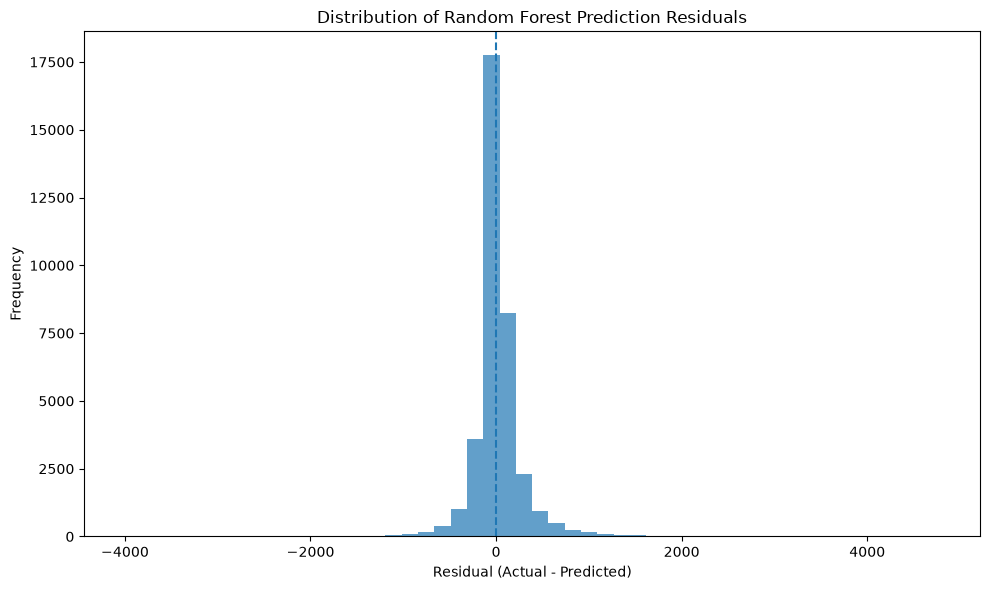

In [32]:
# Plot the distribution of residuals

plt.figure(figsize=(10, 6))

plt.hist(
    residuals,
    bins=50,
    alpha=0.7
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Random Forest Prediction Residuals")

plt.tight_layout()
plt.show()

### 1.28 Interpretation of Residual Distribution

The residual distribution is strongly concentrated around zero, indicating that most of the prediction errors are relatively small.

The residuals occur on both sides of zero, showing that the model produces both underpredictions and overpredictions. The distribution also contains a smaller number of larger residuals, representing rental listings for which the model produces relatively larger prediction errors.

The residual distribution is consistent with the residual summary, where the median residual is close to zero at $0.51, while the mean residual is $27.64. This indicates that the typical prediction error is centered close to zero, although some larger errors influence the mean.

Overall, the residual analysis indicates that the Random Forest model does not show a large systematic shift toward either underprediction or overprediction for the majority of observations.

### 1.29 Residuals vs Predicted Rental Prices

The relationship between residuals and predicted rental prices is examined to identify systematic patterns in the model's prediction errors.

A well-behaved residual plot should show errors distributed around zero without a clear systematic pattern. Increasing dispersion at higher predicted prices may indicate that prediction errors become larger for more expensive rental properties.

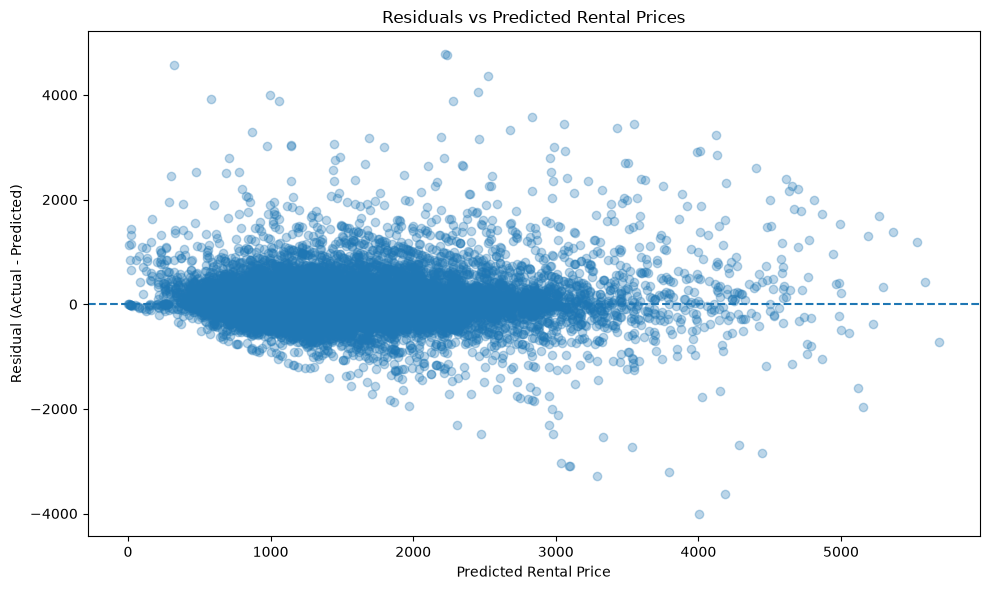

In [33]:
# Plot residuals against predicted rental prices

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.3
)

# Zero-error reference line
plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Rental Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Rental Prices")

plt.tight_layout()
plt.show()

### 1.30 Interpretation of Residuals vs Predicted Prices

The residuals are distributed around the zero reference line across the range of predicted rental prices, indicating that the model produces both underpredictions and overpredictions.

No strong systematic pattern is visible in the residuals, suggesting that the model does not show a substantial consistent bias across the predicted-price range.

However, the spread of the residuals becomes wider for some higher predicted rental prices. This indicates that the model produces larger prediction errors for certain higher-priced rental properties.

Overall, the residual analysis indicates that the Random Forest model captures the general relationship between the input features and rental prices, while some individual high-priced listings remain more difficult to predict accurately.

### 1.31 Final Random Forest Baseline Model Summary

The Random Forest regression model was developed using a leakage-aware preprocessing workflow and evaluated using 3-fold cross-validation followed by evaluation on an untouched test dataset.

The model achieved the following average cross-validation performance:

- Mean MAE: $170.22
- Mean RMSE: $318.87
- Mean R²: 0.7756

After retraining the model using the complete training dataset, the final model achieved the following performance on the unseen test dataset:

- Test MAE: $159.09
- Test RMSE: $303.69
- Test R²: 0.7918

The feature importance analysis identified `region_encoded`, `sqfeet`, `long`, and `lat` as the most influential processed features.

The actual-versus-predicted analysis showed a clear positive relationship between observed and predicted rental prices. Residual analysis showed that errors were generally centered around zero, although larger errors were observed for some higher-priced rental listings.

Overall, the Random Forest model provides a strong predictive baseline for estimating rental prices from the selected property, geographic, and listing characteristics.

### 2. Hyperparameter Tuning

Hyperparameter tuning is performed to investigate whether the performance of the baseline Random Forest model can be improved by adjusting its hyperparameters.

The tuning process uses the training dataset with 3-fold cross-validation. The test dataset remains completely untouched during hyperparameter selection to prevent data leakage.

Several Random Forest configurations will be evaluated by varying important hyperparameters such as the number of trees, maximum tree depth, minimum samples required at a leaf node, and the number of features considered at each split.

The configurations will be compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R². The best-performing configuration will then be used for further evaluation.

#### 2.1 Defining Candidate Hyperparameter Configurations

A controlled hyperparameter search is used to evaluate several Random Forest configurations.

The baseline configuration is included as a reference point, while additional configurations modify the tree depth, number of trees, minimum leaf size, and number of features considered at each split.

In [34]:
rf_configs = [
    {
        "name": "Baseline",
        "n_estimators": 100,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": 1.0
    },
    {
        "name": "Tuned_1",
        "n_estimators": 150,
        "max_depth": 20,
        "min_samples_leaf": 1,
        "max_features": 1.0
    },
    {
        "name": "Tuned_2",
        "n_estimators": 150,
        "max_depth": 25,
        "min_samples_leaf": 2,
        "max_features": 1.0
    },
    {
        "name": "Tuned_3",
        "n_estimators": 200,
        "max_depth": 25,
        "min_samples_leaf": 2,
        "max_features": 0.7
    }
]

for config in rf_configs:
    print(config)

{'name': 'Baseline', 'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 1.0}
{'name': 'Tuned_1', 'n_estimators': 150, 'max_depth': 20, 'min_samples_leaf': 1, 'max_features': 1.0}
{'name': 'Tuned_2', 'n_estimators': 150, 'max_depth': 25, 'min_samples_leaf': 2, 'max_features': 1.0}
{'name': 'Tuned_3', 'n_estimators': 200, 'max_depth': 25, 'min_samples_leaf': 2, 'max_features': 0.7}


#### 2.2 Hyperparameter Search

Each Random Forest configuration is evaluated using the same 3-fold cross-validation strategy used for the baseline model.

For each fold, the preprocessing steps are fitted only on the training portion of the data. The `region` feature is target encoded using the corresponding training fold, and the rental-price target is log-transformed before model training.

The trained model generates predictions for the validation fold, which are converted back to the original rental-price scale before calculating MAE, RMSE, and R².

The mean performance across the three folds is recorded for each hyperparameter configuration.

In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tuning_results = []

for config in rf_configs:

    fold_mae = []
    fold_rmse = []
    fold_r2 = []

    print(f"\nEvaluating: {config['name']}")

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y), start=1):

        # Split data for the current fold
        X_train_fold = X.iloc[train_idx].copy()
        X_valid_fold = X.iloc[valid_idx].copy()

        y_train_fold = y.iloc[train_idx]
        y_valid_fold = y.iloc[valid_idx]

        # Target encode region using training fold only
        X_train_encoded, X_valid_encoded = target_encode_train_valid(
            X_train_fold,
            y_train_fold,
            X_valid_fold,
            column="region",
            smoothing=10
        )

        # Create a fresh preprocessing pipeline for this fold
        fold_preprocessor = ColumnTransformer([
            (
                "numerical",
                numerical_pipeline,
                numerical_features + ["region_encoded"]
            ),
            (
                "categorical",
                categorical_pipeline,
                other_categorical_features
            ),
            (
                "binary",
                "passthrough",
                binary_features
            )
        ])

        # Fit preprocessing only on training fold
        X_train_processed = fold_preprocessor.fit_transform(X_train_encoded)

        # Transform validation fold
        X_valid_processed = fold_preprocessor.transform(X_valid_encoded)

        # Log-transform target
        y_train_log = np.log1p(y_train_fold)

        # Create Random Forest model
        model = RandomForestRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"],
            max_features=config["max_features"],
            random_state=42,
            n_jobs=2
        )

        # Train model
        model.fit(X_train_processed, y_train_log)

        # Generate validation predictions
        y_valid_pred_log = model.predict(X_valid_processed)

        # Convert predictions back to original price scale
        y_valid_pred = np.expm1(y_valid_pred_log)

        # Calculate evaluation metrics
        fold_mae.append(
            mean_absolute_error(y_valid_fold, y_valid_pred)
        )

        fold_rmse.append(
            np.sqrt(mean_squared_error(y_valid_fold, y_valid_pred))
        )

        fold_r2.append(
            r2_score(y_valid_fold, y_valid_pred)
        )

    # Store mean CV results
    tuning_results.append({
        "Configuration": config["name"],
        "Mean MAE": np.mean(fold_mae),
        "Mean RMSE": np.mean(fold_rmse),
        "Mean R²": np.mean(fold_r2)
    })

    print(f"Mean MAE  : {np.mean(fold_mae):.2f}")
    print(f"Mean RMSE : {np.mean(fold_rmse):.2f}")
    print(f"Mean R²   : {np.mean(fold_r2):.4f}")


# Convert results into a DataFrame
tuning_results_df = pd.DataFrame(tuning_results)

print("\nHyperparameter Tuning Results")
display(tuning_results_df)


Evaluating: Baseline
Mean MAE  : 170.22
Mean RMSE : 318.87
Mean R²   : 0.7756

Evaluating: Tuned_1
Mean MAE  : 180.21
Mean RMSE : 323.27
Mean R²   : 0.7693

Evaluating: Tuned_2
Mean MAE  : 173.67
Mean RMSE : 319.78
Mean R²   : 0.7743

Evaluating: Tuned_3
Mean MAE  : 172.01
Mean RMSE : 316.11
Mean R²   : 0.7794

Hyperparameter Tuning Results


,Configuration,Mean MAE,Mean RMSE,Mean R²
0,Baseline,170.219402,318.870419,0.775565
1,Tuned_1,180.208620,323.271353,0.769333
2,Tuned_2,173.673260,319.781457,0.774284
3,Tuned_3,172.005898,316.111939,0.779435


#### 2.3 Tuning Results

The hyperparameter tuning experiment evaluated four Random Forest configurations using 3-fold cross-validation.

The baseline configuration achieved a Mean MAE of 170.22, Mean RMSE of 318.87, and Mean R² of 0.7756.

Among the tuned configurations, Tuned_3 achieved the lowest Mean RMSE of 316.11 and the highest Mean R² of 0.7794. However, the baseline configuration achieved the lowest Mean MAE of 170.22.

Based on the overall cross-validation results, Tuned_3 is selected as the configuration to carry forward for further evaluation. Its performance will be evaluated on the untouched test dataset before making a final decision about the Random Forest model.

#### 2.4 Baseline vs Tuned Random Forest

The hyperparameter tuning results are compared with the baseline Random Forest configuration to determine whether the selected configuration provides an improvement in cross-validation performance.

The comparison considers MAE, RMSE, and R². Lower MAE and RMSE indicate smaller prediction errors, while a higher R² indicates that the model explains more variation in rental prices.


In [36]:
comparison_df = tuning_results_df.copy()

comparison_df["MAE Improvement"] = (
    comparison_df["Mean MAE"].iloc[0] - comparison_df["Mean MAE"]
)

comparison_df["RMSE Improvement"] = (
    comparison_df["Mean RMSE"].iloc[0] - comparison_df["Mean RMSE"]
)

comparison_df["R² Improvement"] = (
    comparison_df["Mean R²"] - comparison_df["Mean R²"].iloc[0]
)

display(comparison_df)

,Configuration,Mean MAE,Mean RMSE,Mean R²,MAE Improvement,RMSE Improvement,R² Improvement
0,Baseline,170.219402,318.870419,0.775565,0.000000,0.000000,0.000000
1,Tuned_1,180.208620,323.271353,0.769333,-9.989219,-4.400934,-0.006233
2,Tuned_2,173.673260,319.781457,0.774284,-3.453858,-0.911038,-0.001282
3,Tuned_3,172.005898,316.111939,0.779435,-1.786496,2.758480,0.003870


#### 2.5 Training the Tuned Random Forest

Based on the cross-validation results, the Tuned_3 configuration is carried forward for further evaluation.

The selected configuration uses 200 trees, a maximum tree depth of 25, a minimum of 2 samples per leaf, and 70% of the features considered at each split.

The model is retrained using the complete training dataset. The preprocessing steps are fitted using only the training data, while the test dataset remains untouched until final evaluation.

In [37]:
tuned_rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=25,
    min_samples_leaf=2,
    max_features=0.7,
    random_state=42,
    n_jobs=2
)

tuned_rf_model.fit(X_full_processed, y_full_log)

print("Tuned Random Forest training completed.")

Tuned Random Forest training completed.


#### 2.6 Generating Predictions from the Tuned Random Forest

The trained Tuned Random Forest model is used to generate predictions for the untouched test dataset.

The model predicts the log-transformed rental prices, so the predictions are converted back to the original rental-price scale using the inverse of the log transformation.

In [38]:
# Generate predictions on the untouched test set
y_test_pred_tuned_log = tuned_rf_model.predict(X_test_processed)

# Convert predictions back to the original price scale
y_test_pred_tuned = np.expm1(y_test_pred_tuned_log)

print("Number of predictions:", len(y_test_pred_tuned))
print("Sample predictions:", y_test_pred_tuned[:5])

Number of predictions: 35920
Sample predictions: [1273.17277635 4366.31326484  901.47777377  744.72284321 1339.80257084]


#### 2.7 Tuned Random Forest Test Evaluation

The Tuned Random Forest is evaluated on the untouched test dataset using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R².

These results are compared with the baseline Random Forest test performance to determine whether the tuned configuration improves generalization to unseen rental listings.

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_tuned = mean_absolute_error(
    y_test_original,
    y_test_pred_tuned
)

rmse_tuned = np.sqrt(
    mean_squared_error(
        y_test_original,
        y_test_pred_tuned
    )
)

r2_tuned = r2_score(
    y_test_original,
    y_test_pred_tuned
)

print(f"Tuned RF Test MAE  : {mae_tuned:.2f}")
print(f"Tuned RF Test RMSE : {rmse_tuned:.2f}")
print(f"Tuned RF Test R²   : {r2_tuned:.4f}")

Tuned RF Test MAE  : 161.40
Tuned RF Test RMSE : 301.84
Tuned RF Test R²   : 0.7943


#### 2.8 Baseline vs Tuned Random Forest

The baseline and tuned Random Forest models are compared using their performance on the untouched test dataset.

The tuned model achieved a lower RMSE and a slightly higher R² than the baseline model. However, its MAE increased slightly.

The tuned Random Forest achieved an RMSE of $301.84 and an R² of 0.7943, compared with $303.69 and 0.7918 for the baseline model. The MAE increased from $159.09 to $161.40.

These results indicate that the tuned configuration provides a small improvement in overall squared-error performance and explained variance, while the baseline model produces a slightly lower average absolute error.

#### 2.9 Random Forest Tuning Conclusion

The hyperparameter tuning experiment evaluated four Random Forest configurations using 3-fold cross-validation.

The selected Tuned_3 configuration used 200 trees, a maximum depth of 25, a minimum leaf size of 2, and 70% of the features at each split.

On the untouched test dataset, the tuned model achieved:

- MAE: $161.40
- RMSE: $301.84
- R²: 0.7943

Compared with the baseline Random Forest, the tuned model produced a small improvement in RMSE and R², while the baseline achieved a slightly lower MAE.

Therefore, the tuning process demonstrated that adjusting the Random Forest hyperparameters can slightly improve its overall squared-error performance and explained variance, although the improvement was relatively small.